# Exploración de datos: localización subcelular de proteínas

Este notebook trabaja sobre los archivos que ya vienen generados por `01_construir_dataset.py`:

- `features_composicion_fisicoquimicos.csv` — accession, sequence, length, bag of aminoácidos (20), features fisicoquímicos (10), localization
- `features_dipeptidos_fisicoquimicos.csv` — accession, sequence, length, dipéptidos (400), features fisicoquímicos (10), localization

El objetivo es explorar visualmente estos datos **antes** de pasar a Orange, para tener una
intuición de qué representa cada clase y qué features podrían ser más útiles.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

comp = pd.read_csv("features_composicion_fisicoquimicos.csv")
dip = pd.read_csv("features_dipeptidos_fisicoquimicos.csv")

AMINOACIDOS = list("ACDEFGHIKLMNPQRSTVWY")
FISICOQUIMICOS = ["peso_molecular", "punto_isoelectrico", "hidrofobicidad_promedio",
                   "aromaticidad", "indice_inestabilidad", "carga_neta_pH7"]

sns.set_style("whitegrid")
comp.head()

## 1. Balance de clases

**Prompt sugerido para la IA (referencia):**

> "Con este DataFrame de pandas `comp`, que tiene una columna categórica `localization`
con 3 valores posibles, generá un gráfico de barras (countplot de seaborn) que muestre
cuántas proteínas hay de cada clase. Agregale título y ejes."”

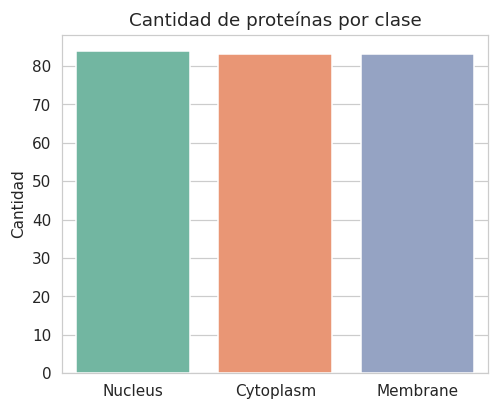

In [ ]:
plt.figure(figsize=(5, 4))
order = comp["localization"].value_counts().index
sns.countplot(data=comp, x="localization", order=order, palette="Set2")
plt.title("Cantidad de proteínas por clase")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.show()

**Interpretación:** ¿Las clases están razonablemente balanceadas?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 2. Distribución de longitud por clase

**Prompt sugerido para la IA (referencia):**

> "Con el mismo DataFrame `comp`, que además tiene una columna numérica `length`,
generá un boxplot que compare la distribución de `length` entre las 3 clases de `localization`."”

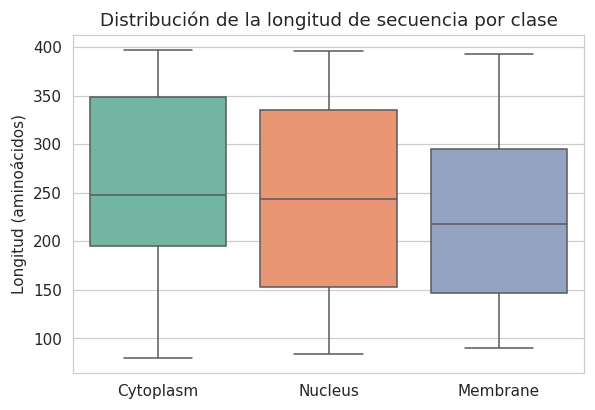

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=comp, x="localization", y="length", palette="Set2")
plt.title("Distribución de la longitud de secuencia por clase")
plt.xlabel("")
plt.ylabel("Longitud (aminoácidos)")
plt.show()

**Interpretación:** ¿Hay diferencias notorias de longitud entre clases? ¿Podría esto sesgar al modelo?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 3. Composición aminoacídica promedio por clase

**Prompt sugerido para la IA (referencia):**

> "Tengo un DataFrame `comp` con 20 columnas (una por aminoácido, con las letras
A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y) que representan proporciones, más una columna
`localization`. Quiero un heatmap donde las filas sean las 3 clases y las columnas los 20
aminoácidos, mostrando el promedio de cada aminoácido por clase. Usá seaborn.heatmap."”

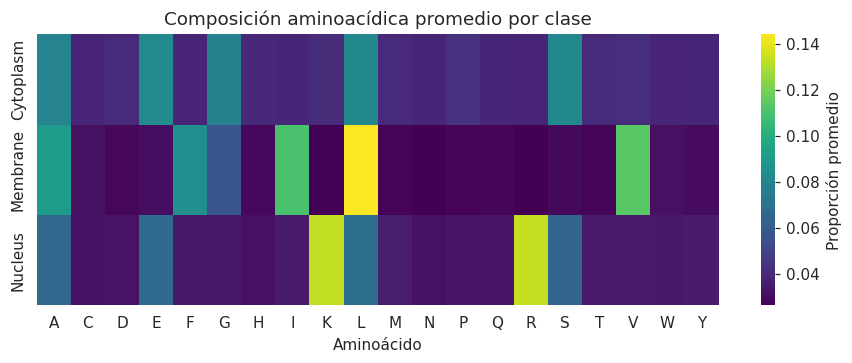

In [ ]:
AMINOACIDOS = list("ACDEFGHIKLMNPQRSTVWY")
promedio_por_clase = comp.groupby("localization")[AMINOACIDOS].mean()

plt.figure(figsize=(10, 3.2))
sns.heatmap(promedio_por_clase, cmap="viridis", cbar_kws={"label": "Proporción promedio"})
plt.title("Composición aminoacídica promedio por clase")
plt.xlabel("Aminoácido")
plt.ylabel("")
plt.show()

**Interpretación:** ¿Qué aminoácidos se ven más distintos entre clases? ¿Coincide con lo que esperarían biológicamente (por ejemplo, aminoácidos hidrofóbicos en membrana)?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 4. Features fisicoquímicos por clase

**Prompt sugerido para la IA (referencia):**

> "Con el DataFrame `comp`, que tiene las columnas ['peso_molecular',
'punto_isoelectrico', 'hidrofobicidad_promedio', 'aromaticidad', 'indice_inestabilidad',
'carga_neta_pH7'] y una columna `localization`, generá una grilla de 2x3 subplots con un
boxplot de cada feature comparando las 3 clases."”

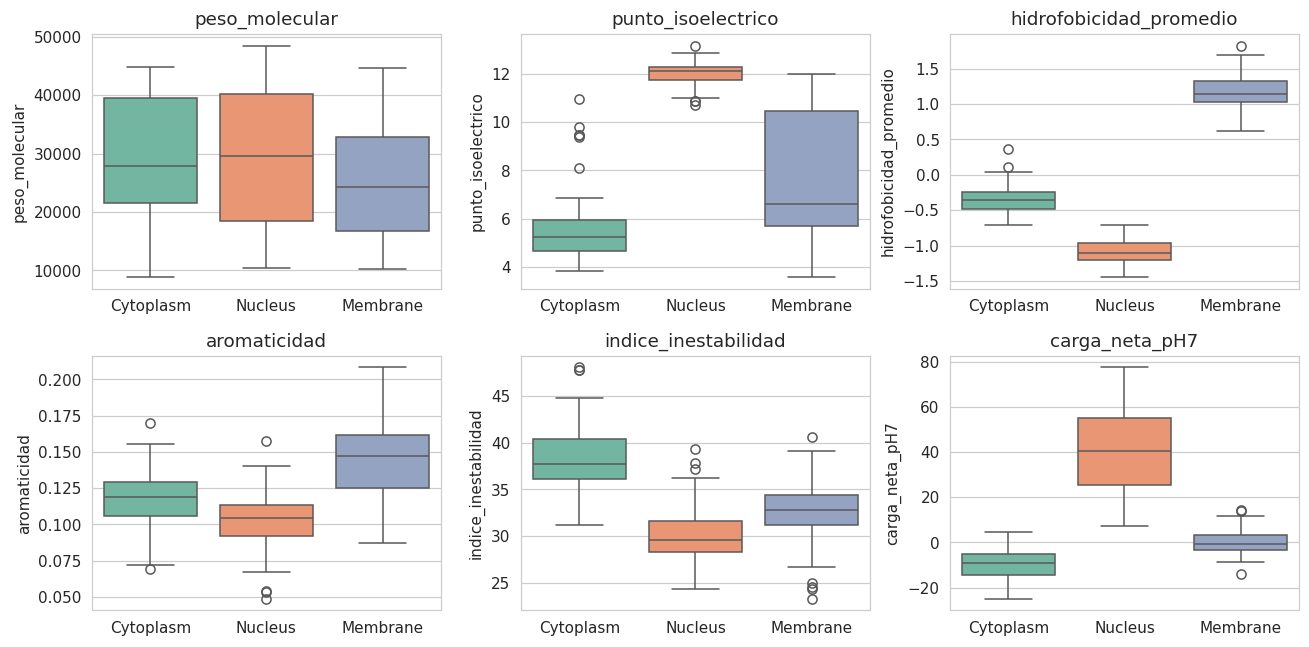

In [ ]:
FISICOQUIMICOS = ["peso_molecular", "punto_isoelectrico", "hidrofobicidad_promedio",
                   "aromaticidad", "indice_inestabilidad", "carga_neta_pH7"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feat in zip(axes.flat, FISICOQUIMICOS):
    sns.boxplot(data=comp, x="localization", y=feat, ax=ax, palette="Set2")
    ax.set_xlabel("")
    ax.set_title(feat)
plt.tight_layout()
plt.show()

**Interpretación:** ¿Cuál de estos features parece separar mejor alguna clase? Anótenlo, lo vamos a poder confirmar después con el widget Rank en Orange.

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 5. Dipéptidos más variables entre clases

**Prompt sugerido para la IA (referencia):**

> "Tengo un DataFrame `dip` con 400 columnas de dipéptidos (nombradas con 2 letras,
por ejemplo 'AA', 'AC', etc.) más una columna `localization`. Quiero: (1) calcular el promedio
de cada dipéptido agrupado por clase, (2) quedarme con los 20 dipéptidos cuya varianza entre
clases sea mayor, y (3) graficar un heatmap de esos 20 dipéptidos (filas=clases, columnas=dipéptidos)."”

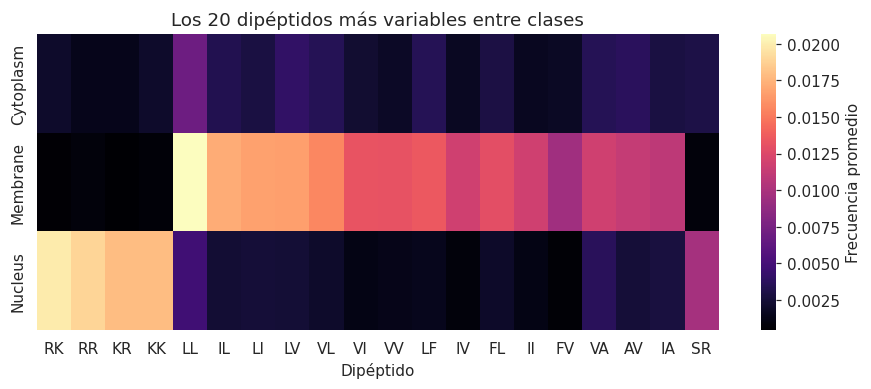

In [ ]:
dip_cols = [c for c in dip.columns if len(c) == 2 and c.isalpha()]
promedio_dip = dip.groupby("localization")[dip_cols].mean()
top20 = promedio_dip.var(axis=0).sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 3.5))
sns.heatmap(promedio_dip[top20], cmap="magma", cbar_kws={"label": "Frecuencia promedio"})
plt.title("Los 20 dipéptidos más variables entre clases")
plt.xlabel("Dipéptido")
plt.ylabel("")
plt.show()

**Interpretación:** ¿Reconocen algún patrón (por ejemplo, dipéptidos con L o V destacándose en Membrana)?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## Síntesis

Con lo explorado en este notebook, respondan brevemente (2-3 líneas cada una):

1. ¿Qué representación (composición o dipéptidos) esperan que separe mejor las clases, según lo que vieron?
2. ¿Qué feature fisicoquímico les parece más prometedor y por qué?
3. ¿Alguna clase se ve claramente más fácil o más difícil de separar que las demás?

Guarden estas respuestas — las van a poder contrastar con los resultados reales que obtengan en Orange.